# Materialize a lakehouse snapshot and verify it

**Goal.** Work through a bounded, reproducible example and inspect the evidence before connecting an external service.

**Prerequisites.** Base FraudTwin install. Optional extras and Docker commands are clearly marked.

**Produces.** Tables, fingerprints, manifests, and verification output.


**Source size.** The default cells generate approximately 1,000 logical payments; increase duration and population together for a 10,000-payment run.

**Offline path.** All marked offline cells run without Docker or network services. Service cells are optional and explicitly marked in notebook metadata.

**Cleanup.** Outputs are written under a temporary directory; remove any local run directory if you changed the output location.


In [1]:
!pip install pyiceberg[s3fs]
!pip install prometheus-client requests

## Optional lakehouse setup
The first cell installs the Iceberg and observability clients. Run the next cell only when you want the local catalog and observability services; Bronze/Silver/Gold materialization works offline.

```bash
docker compose --profile lakehouse --profile observability up -d minio minio-init iceberg-rest prometheus grafana
```

Set `FRAUDTWIN_ICEBERG_CATALOG_URI` when needed. After the services start, open [Prometheus](http://localhost:9090) or [Grafana](http://localhost:3000) in a browser. Starting the services alone does not populate dashboard panels; the notebook chart below is local and immediate. Stop them later with `docker compose --profile lakehouse --profile observability down`.

Grafana stores its password in the persistent volume. If `admin` / `fraudtwin-local` is rejected because Grafana was initialized earlier, stop the stack and remove only the Grafana volume with `docker compose --profile observability down` followed by `docker volume rm fraud-twin_grafana-data`, then rerun the setup cell. This resets Grafana users and dashboards, not project data.

In [2]:
# Run this cell only when Docker services are available.
import os

# Compose requires a Grafana password; replace this local-only default if needed.
os.environ.setdefault("GRAFANA_ADMIN_PASSWORD", "fraudtwin-local")
compose_profiles = "--profile lakehouse --profile observability"
!docker compose {compose_profiles} up -d minio minio-init iceberg-rest prometheus grafana
!docker compose --profile lakehouse --profile observability ps

[+] up 4/5
 ✔ Container fraud-twin-minio-1        Running                              0.0s
 ✔ Container fraud-twin-prometheus-1   Running                              0.0s
 ✔ Container fraud-twin-grafana-1      Running                              0.0s
 ✔ Container fraud-twin-iceberg-rest-1 Running                              0.0s
 ⠋ Container fraud-twin-minio-init-1   Starting                             0.0s
[+] up 4/5
 ✔ Container fraud-twin-minio-1        Running                              0.0s
 ✔ Container fraud-twin-prometheus-1   Running                              0.0s
 ✔ Container fraud-twin-grafana-1      Running                              0.0s
 ✔ Container fraud-twin-iceberg-rest-1 Running                              0.0s
 ⠙ Container fraud-twin-minio-init-1   Starting                             0.1s
[+] up 5/5
 ✔ Container fraud-twin-minio-1        Running                              0.0s
 ✔ Container fraud-twin-prometheus-1   Running                              

**Set up a deterministic source run**


In [3]:
import json
from pathlib import Path

import polars as pl

from fraudtwin.config import load_config
from fraudtwin.generation import generate

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal.yaml").exists()),
    Path.cwd(),
)
base = load_config(root / "configs" / "minimal.yaml")
# Scale the population so the bounded example produces about 1,000 payments.
population = base.population.model_copy(
    update={
        "customers": 200,
        "accounts": 300,
        "cards": 240,
        "devices": 240,
        "pix_keys": 160,
        "merchants": 60,
    }
)
simulation = base.simulation.model_copy(update={"duration_days": 10})
fraud = base.fraud.model_copy(update={"enabled": True, "target_rate": 0.05})
config = base.model_copy(
    update={"population": population, "simulation": simulation, "fraud": fraud}
)
data = generate(config, write=False)
run_id = data.run_id
payments = pl.DataFrame([item.model_dump(mode="json") for item in data.behavior.payments])
print({"run_id": run_id, "payments": len(payments), "events": len(data.behavior.payment_events)})

{'run_id': 'RUN-2a3ad02ee370aeb8', 'payments': 1092, 'events': 4699}


**Inspect schema, grain, and counts**


In [4]:
from fraudtwin.lakehouse import build_bronze_records, logical_fingerprint, silver_rows

bronze = build_bronze_records(data.entities, data.behavior, data.manifest)
silver = silver_rows(bronze)
print({"bronze": len(bronze), "silver": len(silver)})

{'bronze': 9386, 'silver': 9386}


**Visualize the materialized layers**

The chart is computed locally, so it works even when the optional Docker services are stopped.

shape: (2, 2)
┌────────┬──────┐
│ layer  ┆ rows │
│ ---    ┆ ---  │
│ str    ┆ i64  │
╞════════╪══════╡
│ Bronze ┆ 9386 │
│ Silver ┆ 9386 │
└────────┴──────┘


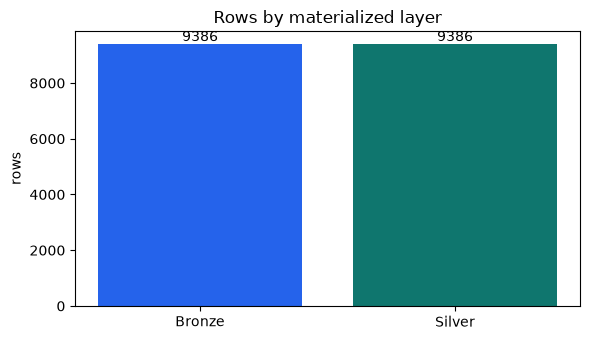

In [5]:
layer_counts = pl.DataFrame({"layer": ["Bronze", "Silver"], "rows": [len(bronze), len(silver)]})
print(layer_counts)
try:
    import matplotlib.pyplot as plt

    figure, axis = plt.subplots(figsize=(6, 3.5))
    axis.bar(
        layer_counts["layer"].to_list(),
        layer_counts["rows"].to_list(),
        color=["#2563eb", "#0f766e"],
    )
    axis.set(title="Rows by materialized layer", ylabel="rows")
    axis.bar_label(axis.containers[0], fmt="%d")
    figure.tight_layout()
    plt.show()
    plt.close(figure)
except ImportError:
    print("Install matplotlib to render the layer-size chart.")

**Run the core operation**


In [6]:
fingerprint_before = logical_fingerprint(silver)
print("snapshot fingerprint:", f"{fingerprint_before[:12]}...")

snapshot fingerprint: 760720c0370f...


**Measure and interpret the result**


In [7]:
backfill = silver_rows([*bronze, bronze[0]])
print({"before": len(silver), "after_dedup": len(backfill), "late_event": bronze[0].record_id})

{'before': 9386, 'after_dedup': 9386, 'late_event': 'EVT-F01-000001-000001'}


**Exercise a parameter or failure mode**


In [8]:
assert logical_fingerprint(silver) == fingerprint_before
print({"slo": {"duplicate_rate": 0.0, "reconciliation": "passed"}})

{'slo': {'duplicate_rate': 0.0, 'reconciliation': 'passed'}}


**Write a compact artifact and fingerprint**


Optional: configure PyIceberg and run materialize_run for real snapshots; offline checks stay deterministic.


**Verify invariants and clean up**


In [9]:
# A compact inspection is more useful than printing an entire run.
sample_columns = [
    c for c in ("payment_id", "amount", "initiated_at", "payer_account_id") if c in payments.columns
]
sample_rows = payments.select(sample_columns).head(8).to_dicts()
print(f"Sample payments ({len(sample_rows)} of {payments.height} rows):")
for row in sample_rows:
    print(
        f"  - {row.get('payment_id')}: amount={row.get('amount')}, "
        f"initiated_at={row.get('initiated_at')}, payer={row.get('payer_account_id')}"
    )
nulls = {name: count for name, count in payments.null_count().to_dicts()[0].items() if count}
print("\nData quality summary:")
print(f"  rows: {payments.height}")
print(f"  columns: {payments.width}")
if not nulls:
    print("  nulls: none")
else:
    print("  columns with nulls:")
    for name, count in sorted(nulls.items()):
        print(f"    - {name}: {count}")

Sample payments (8 of 1092 rows):
  - PAY-00000001: amount=70.7, initiated_at=2026-01-03T16:25:00Z, payer=ACC-000123
  - PAY-00000002: amount=25.52, initiated_at=2026-01-05T11:37:00Z, payer=ACC-000174
  - PAY-00000003: amount=18.37, initiated_at=2026-01-05T11:21:00Z, payer=ACC-000174
  - PAY-00000004: amount=5.54, initiated_at=2026-01-02T22:30:00Z, payer=ACC-000003
  - PAY-00000005: amount=13.71, initiated_at=2026-01-02T09:41:00Z, payer=ACC-000029
  - PAY-00000006: amount=70.06, initiated_at=2026-01-04T10:40:00Z, payer=ACC-000179
  - PAY-00000007: amount=42.73, initiated_at=2026-01-02T18:04:00Z, payer=ACC-000247
  - PAY-00000008: amount=36.42, initiated_at=2026-01-05T09:27:00Z, payer=ACC-000255

Data quality summary:
  rows: 1092
  columns: 15
  columns with nulls:
    - card_id: 565
    - merchant_id: 565
    - payee_account_id: 86
    - payee_institution_id: 86
    - payee_pix_key_id: 857
    - payer_institution_id: 86
    - payer_pix_key_id: 857


## Optional: publish a completed run to Grafana

You do not need this section to complete the notebook. The cells above generate and inspect the data locally. Use this separate workflow only when you want to see a completed CLI run in Grafana: Prometheus scrapes an HTTP endpoint, while the notebook’s in-memory `generate(..., write=False)` call does not start one. The demo uses the small fraud-enabled `difficulty-v1.yaml` fixture; `configs/minimal.yaml` intentionally produces zero fraud events. The timestamped output directory keeps the optional CLI run separate from earlier or partial runs. Use two terminals: start the generator in Terminal A and keep it running, then run the check below in Terminal B before Terminal A returns to its prompt:

```bash
run_dir="outputs/grafana-demo-$(date +%Y%m%d-%H%M%S)-$$"
poetry run fraudtwin generate configs/benchmarks/difficulty-v1.yaml \
  --output-dir "$run_dir" \
  --metrics-host 0.0.0.0 \
  --metrics-port 9464 \
  --metrics-hold-seconds 120
```

In Terminal B, verify the endpoint from the host with `curl --fail --retry 20 --retry-connrefused --retry-delay 1 http://localhost:9464/metrics`; `host.docker.internal:9464` is the address Prometheus uses inside Docker. Confirm that the response contains `events_generated_total{run_id="RUN-..."}` and `generator_errors_total{run_id="RUN-..."} 0.0`; an `unknown` run ID with an error value means the CLI run failed and Grafana has no successful series to show. The endpoint closes after one minute, so a later `connection refused` means Terminal A has already finished. Then open the [FraudTwin run observability dashboard](http://localhost:3000/d/fraudtwin-m27/fraudtwin-run-observability?orgId=1), choose the successful `run_id` created by the command, and refresh the panels. These are completed-batch metrics, so their values remain flat after generation; the target health is the signal that tells you whether the temporary exporter is still available.

Username: `admin`

Password: `fraudtwin-local`

Prometheus scrapes the temporary metrics endpoint at `host.docker.internal:9464`; if the target is down, check [Prometheus targets](http://localhost:9090/targets) and confirm the CLI command is still running.

**Optional service integration**


In [10]:
summary = {
    "run_id": run_id,
    "payments": len(data.behavior.payments),
    "payment_events": len(data.behavior.payment_events),
    "fraud_records": len(data.behavior.fraud_records),
}
assert summary["payments"] == len(payments)
assert summary["payments"] > 0
print(json.dumps(summary, indent=2, default=str))

{
  "run_id": "RUN-2a3ad02ee370aeb8",
  "payments": 1092,
  "payment_events": 4699,
  "fraud_records": 51
}


**Review the expected outcome**


In [11]:
import os

try:
    from pyiceberg.catalog import load_catalog

    catalog = load_catalog(
        "fraudtwin",
        type="rest",
        uri=os.getenv("FRAUDTWIN_ICEBERG_CATALOG_URI", "http://localhost:8181"),
    )
    import requests

    namespaces = catalog.list_namespaces()
    prometheus = requests.get("http://localhost:9090/-/ready", timeout=3)
    checks = pl.DataFrame(
        [
            {
                "check": "Iceberg catalog",
                "status": "connected",
                "details": f"{len(namespaces)} namespaces",
            },
            {
                "check": "Prometheus",
                "status": f"HTTP {prometheus.status_code}",
                "details": "readiness endpoint",
            },
        ]
    )
    print(checks)
except Exception:
    print({"offline_fallback": True})
    print(
        "Optional services are unavailable. Run the setup cell above, then rerun this check; "
        "offline analysis remains available."
    )

shape: (2, 3)
┌─────────────────┬───────────┬────────────────────┐
│ check           ┆ status    ┆ details            │
│ ---             ┆ ---       ┆ ---                │
│ str             ┆ str       ┆ str                │
╞═════════════════╪═══════════╪════════════════════╡
│ Iceberg catalog ┆ connected ┆ 0 namespaces       │
│ Prometheus      ┆ HTTP 200  ┆ readiness endpoint │
└─────────────────┴───────────┴────────────────────┘


## Record the generated shape and tutorial contract.


In [12]:
summary = {
    "payments": len(data.behavior.payments),
    "events": len(data.behavior.payment_events),
}
print(summary)
assert summary["payments"] >= 0

{'payments': 1092, 'events': 4699}


In [13]:
assert fingerprint_before
print({"offline_fallback": True, "fingerprint": f"{fingerprint_before}"})

{'offline_fallback': True, 'fingerprint': '760720c0370fbe9bc23d29486ccf470e460e5b36bb18ecedd3818eb40540d5ae'}
